Задання 1

1. Використовуючи деякі функції дослідницького аналізу, представлені в цьому блокноті, дайте відповідь на наступне щодо набору даних adult.data (можна завантажити тут):

a. Скільки тут рядків і колонок (?) ?

b. Чи містить цей набір даних будь-які нечислові колонки (?) ?

в. Чи є в цьому наборі даних відсутні значення в будь-яких колонках (???) ? Як це дізнатись?

d. Який середній вік осіб, зареєстрованих у цьому наборі даних?

In [16]:
from typing import cast
import numpy as np
import pandas as pd

%matplotlib inline


df_income = cast(pd.DataFrame, pd.read_csv("adult.csv"))
print(df_income.head())

print(f"a. datashape: {df_income.shape}")
print(f"b. has non-numerical columns (yes): {df_income.dtypes[df_income.dtypes == 'str'].count()}")
null_counts = df_income.isnull().sum()
print(f"c. null entries (none): {null_counts[null_counts != 0].count()}")
print(f"d. average age: {np.average(df_income['age'].values)}")

   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-per-week native-country incom

Завдання 2
Проведить EDA по вибраному у попередній роботі набіру даних (або для нового)

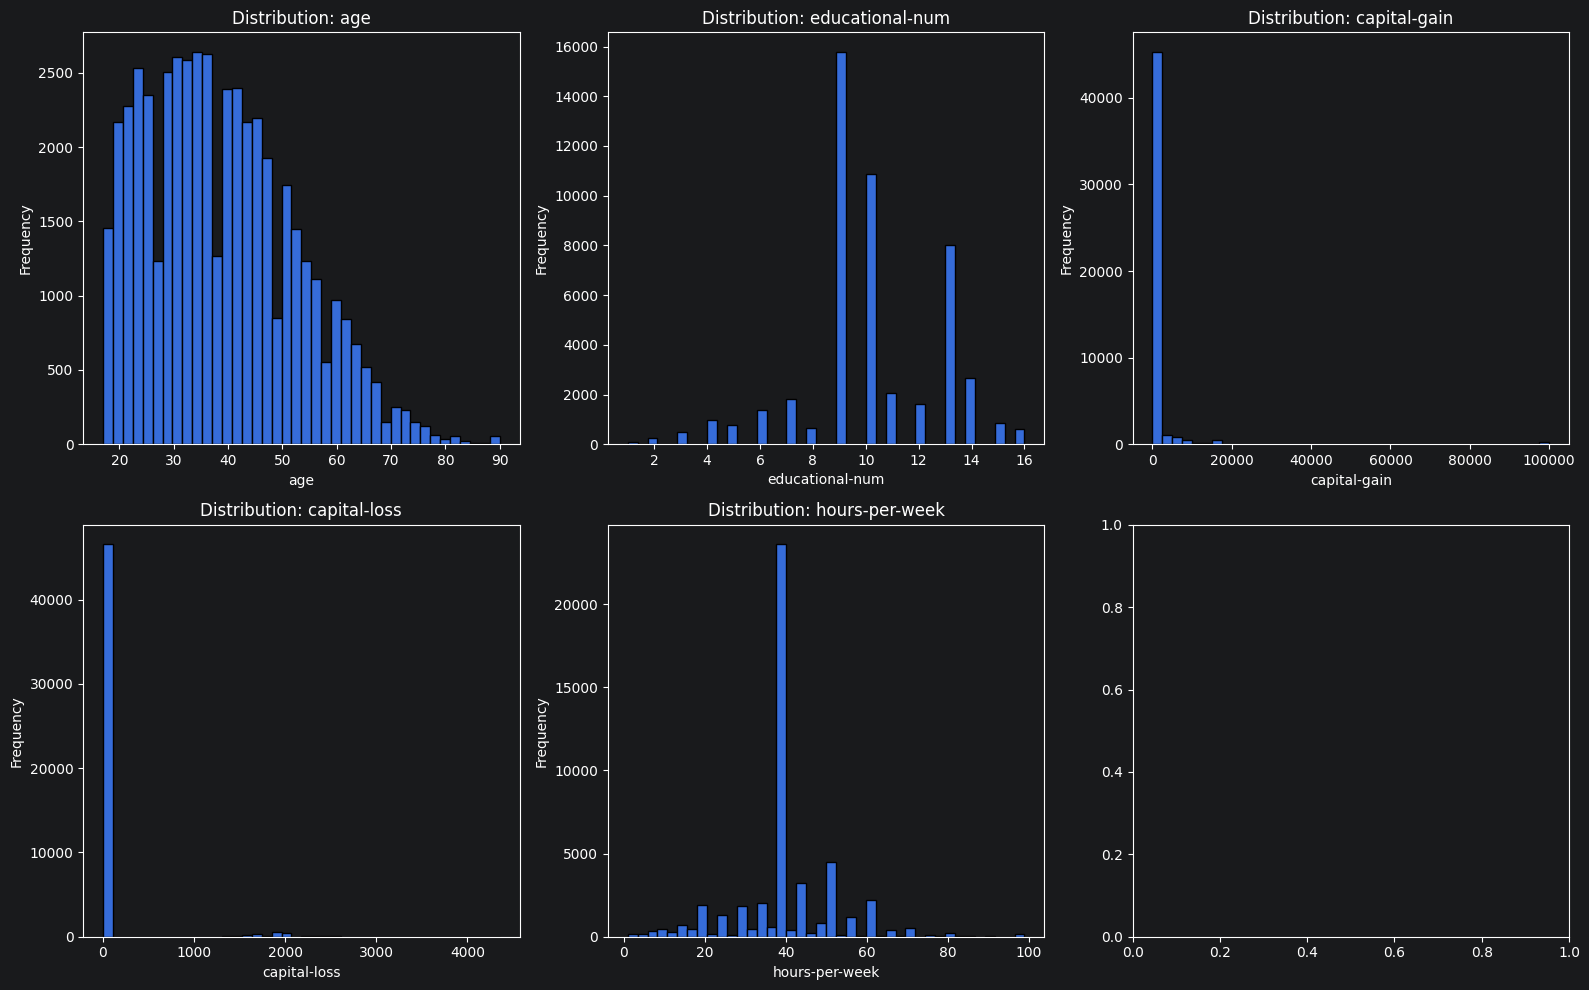

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 1. Numeric feature distributions
num_cols = df_income.select_dtypes(include=np.number).columns.tolist()
if num_cols.count('fnlwgt') > 0:
    num_cols.remove('fnlwgt')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df_income[col], bins=40, edgecolor='black')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

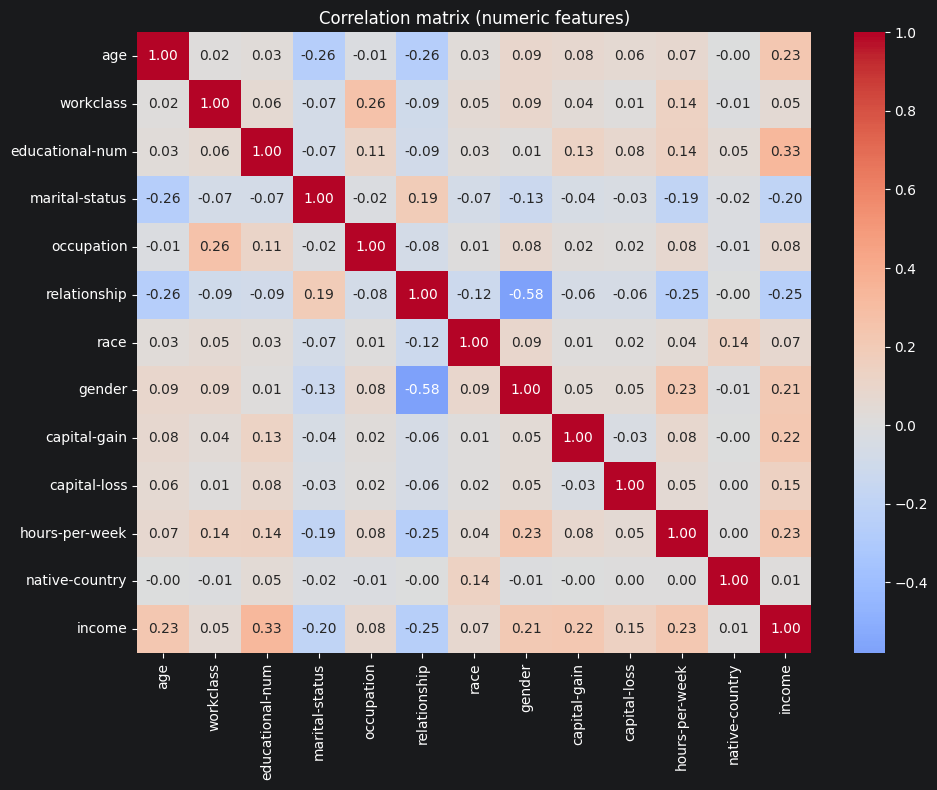

In [28]:
from sklearn.preprocessing import LabelEncoder

# 2. Correlation matrix
plt.figure(figsize=(10, 8))
cols = df_income.columns.tolist()
col_hetamap = df_income.select_dtypes(include=['str', 'object']).columns.tolist()

if 'education' in df_income.columns:
    df_income = df_income.drop(columns=['education'])
if 'fnlwgt' in df_income.columns:
    df_income = df_income.drop(columns=['fnlwgt'])



label_encoders = {}
for col in col_hetamap:
    le = LabelEncoder()
    df_income[col] = le.fit_transform(df_income[col])
    label_encoders[col] = le

corr = df_income[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

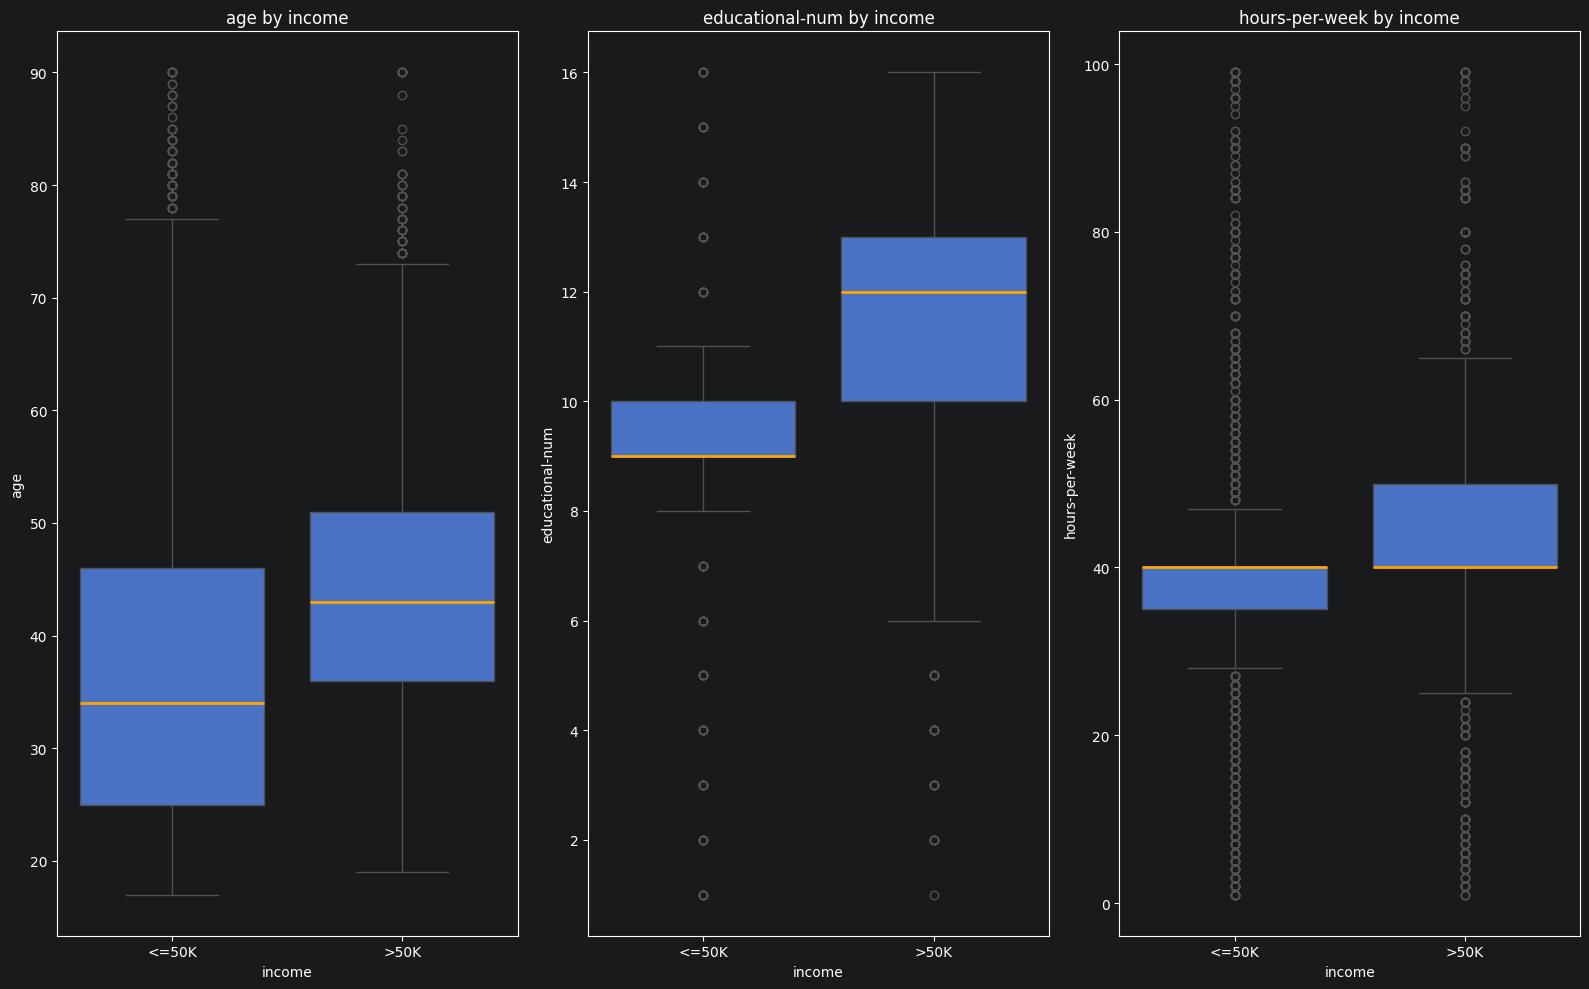

In [4]:
# 3. Boxplots of numeric features by income
fig, axes = plt.subplots(1, 3, figsize=(16, 10))
axes = axes.flatten()
if num_cols.count('capital-gain') > 0:
    num_cols.remove('capital-gain')
if num_cols.count('capital-loss') > 0:
    num_cols.remove('capital-loss')


for i, col in enumerate(num_cols):
    sns.boxplot(data=df_income, x='income', y=col, ax=axes[i], medianprops={'color': 'orange', 'linewidth': 2})
    axes[i].set_title(f'{col} by income')
plt.tight_layout()
plt.show()

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


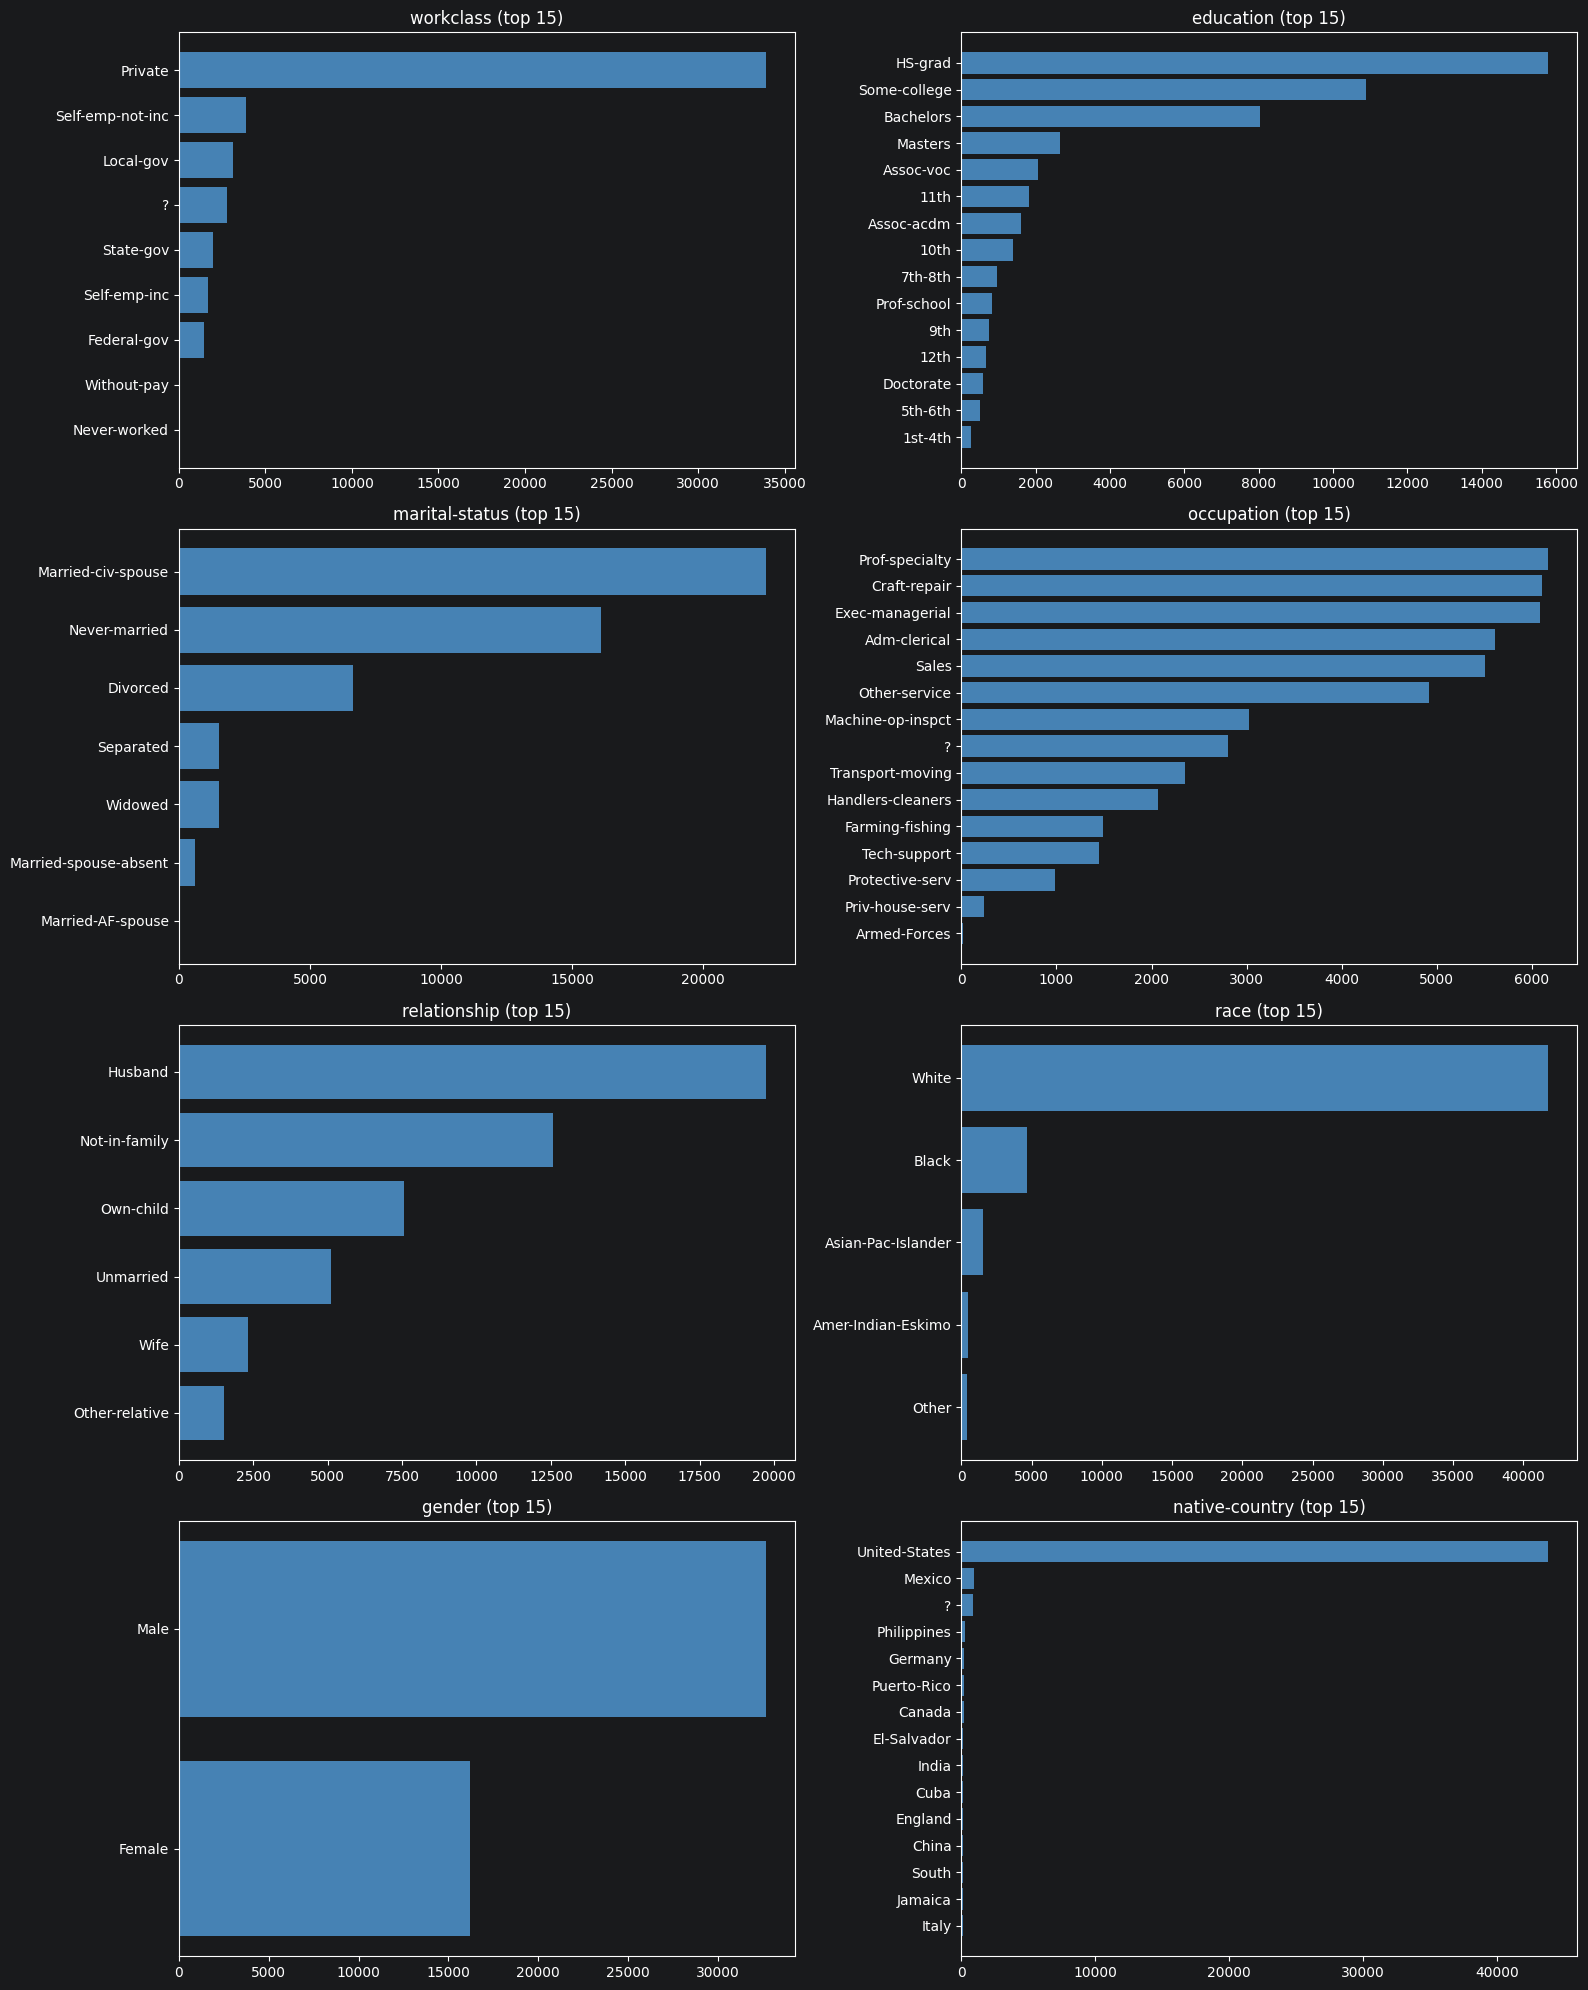

In [5]:
# 4. Categorical features — distribution (top 15)
cat_cols = df_income.select_dtypes(include=['object','str']).columns.tolist()
print(cat_cols)
cat_cols.remove('income')  # target separately

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df_income[col].value_counts().head(15)
    axes[i].barh(counts.index, counts.values, color='steelblue')
    axes[i].set_title(f'{col} (top 15)')
    axes[i].invert_yaxis()
plt.tight_layout()
plt.show()

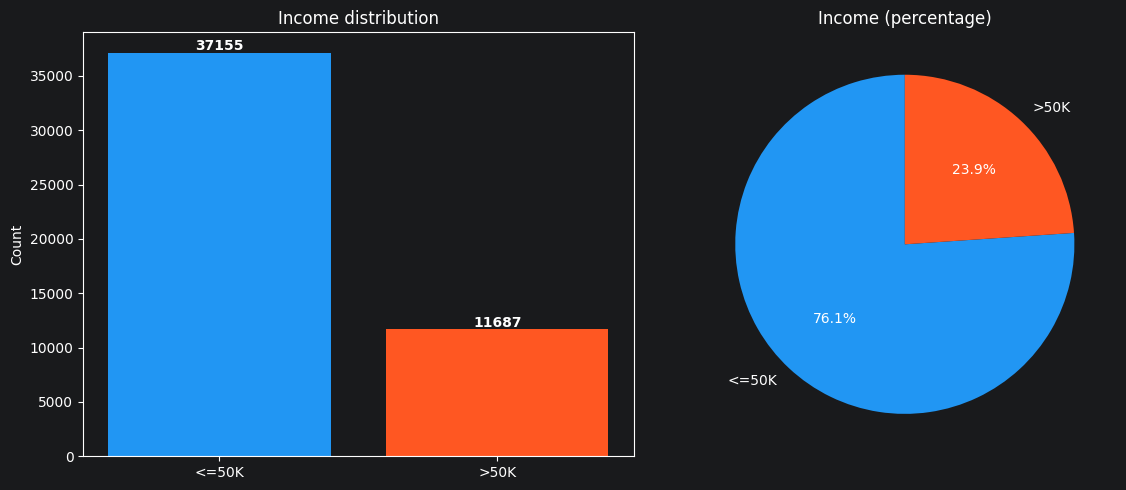


Class balance:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Ratio: 3.18 : 1


In [6]:
# 5. Target variable — income
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution
income_counts = df_income['income'].value_counts()
axes[0].bar(income_counts.index, income_counts.values, color=['#2196F3', '#FF5722'])
axes[0].set_title('Income distribution')
axes[0].set_ylabel('Count')
for j, v in enumerate(income_counts.values):
    axes[0].text(j, v + 200, str(v), ha='center', fontweight='bold')

# Percentage
axes[1].pie(income_counts.values, labels=income_counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#FF5722'], startangle=90)
axes[1].set_title('Income (percentage)')

plt.tight_layout()
plt.show()

print(f"\nClass balance:\n{income_counts}")
print(f"\nRatio: {income_counts.values[0]/income_counts.values[1]:.2f} : 1")

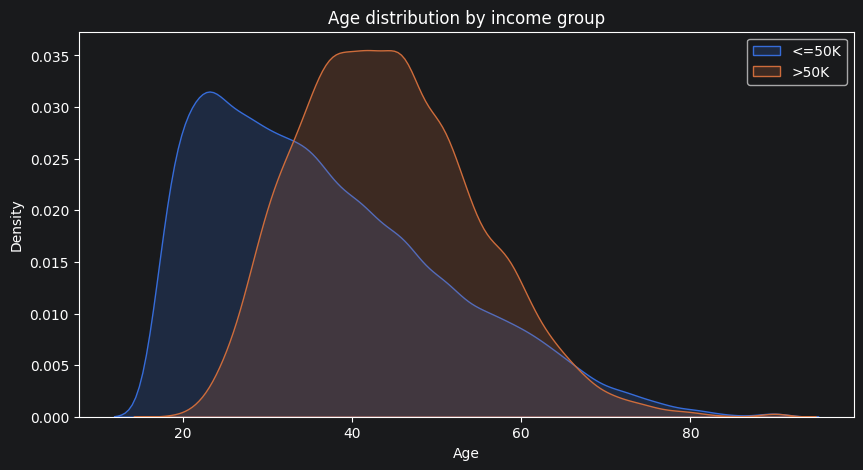

In [7]:
# 6. Age distribution by income — KDE
plt.figure(figsize=(10, 5))
for label in df_income['income'].unique():
    subset = df_income[df_income['income'] == label]
    sns.kdeplot(subset['age'], label=label, fill=True, alpha=0.2)
plt.title('Age distribution by income group')
plt.xlabel('Age')
plt.legend()
plt.show()

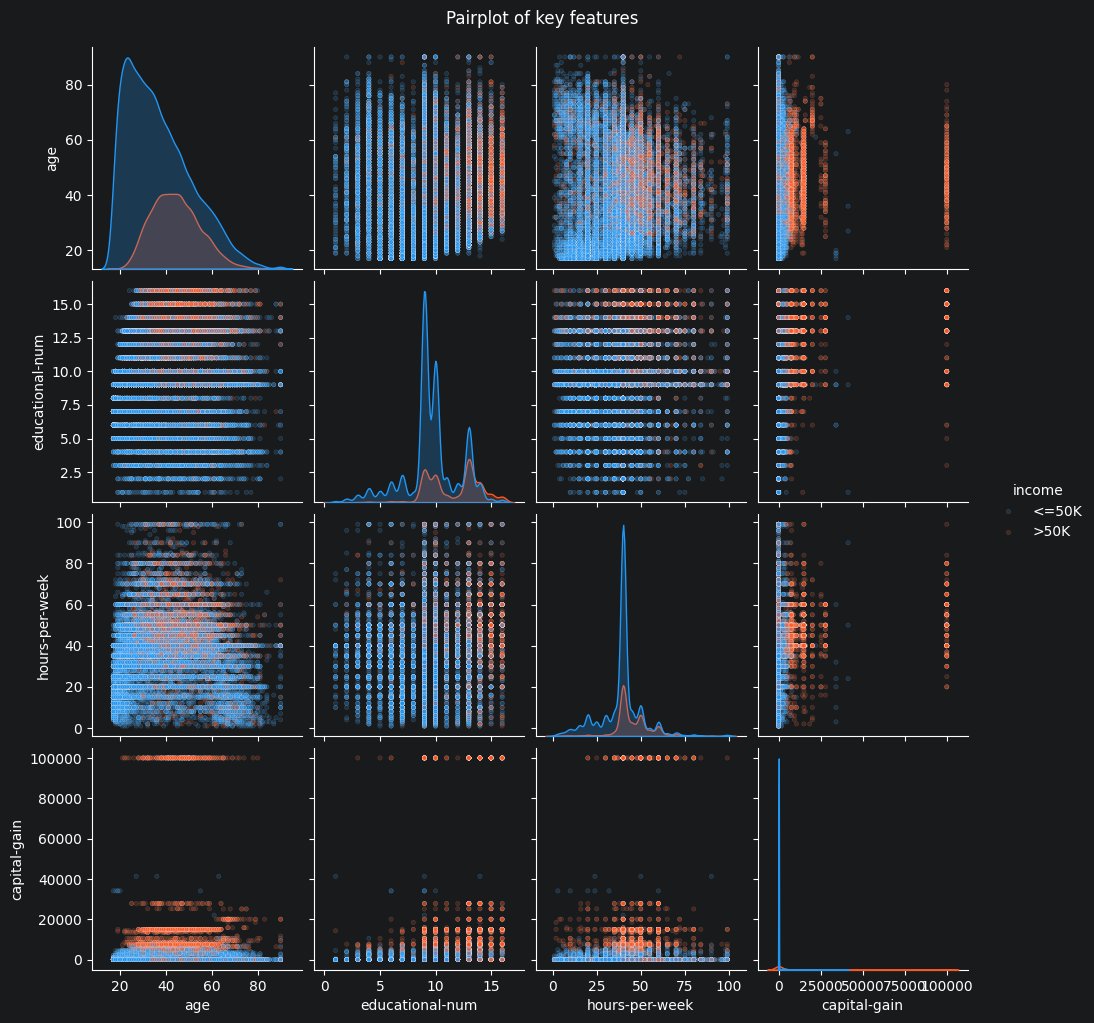

In [8]:
# 7. Pairplot of key numeric features
sns.pairplot(df_income[['age', 'educational-num', 'hours-per-week', 'capital-gain', 'income']],
             hue='income', diag_kind='kde', palette={'<=50K': '#2196F3', '>50K': '#FF5722'},
             plot_kws={'alpha': 0.2, 's': 10})
plt.suptitle('Pairplot of key features', y=1.02)
plt.show()